<a href="https://colab.research.google.com/github/D-Rockie/Deep-Learning-Lab-2026/blob/main/DLexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikeras "scikit-learn==1.5.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 32.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import keras
from keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print("Train images:", x_train.shape, "labels:", y_train.shape)
print("Test images :", x_test.shape, "labels:", y_test.shape)
print("Pixel range :", x_train.min(), "to", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28) labels: (60000,)
Test images : (10000, 28, 28) labels: (10000,)
Pixel range : 0 to 255


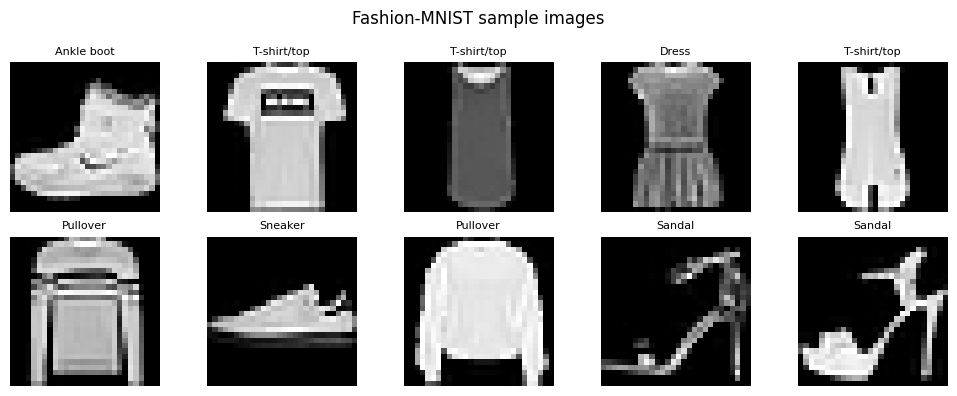

In [3]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Fashion-MNIST sample images")
plt.tight_layout()
plt.show()

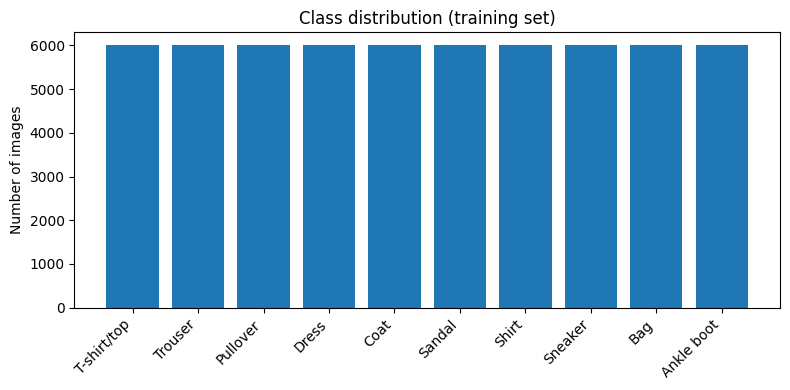

In [4]:
values, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8,4))
plt.bar([class_names[v] for v in values], counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images")
plt.title("Class distribution (training set)")
plt.tight_layout()
plt.show()

In [5]:
# Flatten 28x28 -> 784, and cast to float
x_train_flat = x_train.reshape(-1, 784).astype("float32")
x_test_flat  = x_test.reshape(-1, 784).astype("float32")

# Normalize pixels to [0,1]
x_train_flat /= 255.0
x_test_flat  /= 255.0

# One-hot labels — only for the baseline (categorical_crossentropy)
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

print("Images before:", x_train.shape, "-> after:", x_train_flat.shape)
print("Labels before:", y_train.shape, "-> one-hot:", y_train_oh.shape)

Images before: (60000, 28, 28) -> after: (60000, 784)
Labels before: (60000,) -> one-hot: (60000, 10)


In [6]:
baseline = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax'),
])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
baseline.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

t0 = time.time()
history = baseline.fit(x_train_flat, y_train_oh,
                       validation_split=0.1,
                       epochs=20, batch_size=32, verbose=1)
baseline_train_time = time.time() - t0
print(f"Baseline training time: {baseline_train_time:.1f}s")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8207 - loss: 0.5045 - val_accuracy: 0.8608 - val_loss: 0.3785
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8661 - loss: 0.3687 - val_accuracy: 0.8625 - val_loss: 0.3883
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8764 - loss: 0.3348 - val_accuracy: 0.8800 - val_loss: 0.3363
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8850 - loss: 0.3096 - val_accuracy: 0.8825 - val_loss: 0.3308
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8911 - loss: 0.2939 - val_accuracy: 0.8832 - val_loss: 0.3200
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8961 - loss: 0.2776 - val_accuracy: 0.8787 - val_loss: 0.3471
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9008 - loss: 0.2653 - val_accuracy: 0.8807 - val_loss: 0.3395
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9018 - loss: 0.2566 -

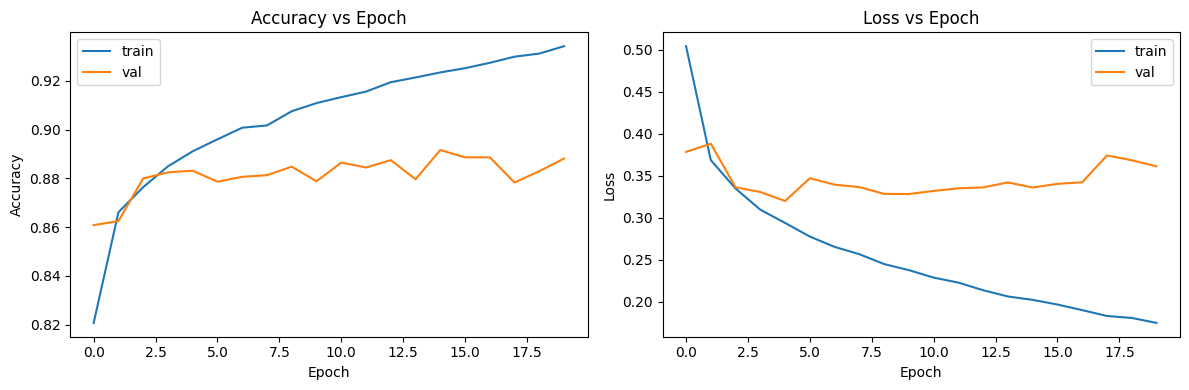

In [8]:
h = history.history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(h['accuracy'], label='train'); plt.plot(h['val_accuracy'], label='val')
plt.title('Accuracy vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(h['loss'], label='train'); plt.plot(h['val_loss'], label='val')
plt.title('Loss vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy 0.8849 | Precision 0.8871 | Recall 0.8849 | F1 0.8855

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.81      0.80      0.80      1000
       Dress       0.85      0.92      0.88      1000
        Coat       0.81      0.81      0.81      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.70      0.75      0.72      1000
     Sneaker       0.94      0.95      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.88      0.89     10000



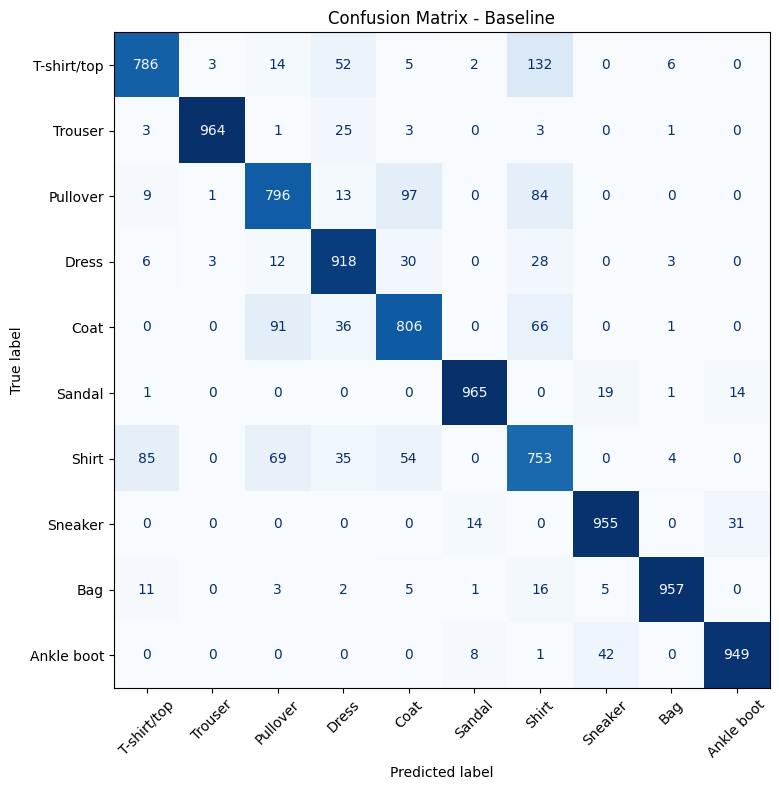

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

y_pred = np.argmax(baseline.predict(x_test_flat), axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy {acc:.4f} | Precision {prec:.4f} | Recall {rec:.4f} | F1 {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Baseline'); plt.tight_layout(); plt.show()

In [10]:
import sklearn
print(sklearn.__version__)

1.5.2


In [11]:
!pip install -q "scikit-learn==1.5.2"

In [12]:
import sklearn
print(sklearn.__version__)

1.5.2


In [13]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# meta is auto-injected by SciKeras (gives n_features_in_ and n_classes_)
def get_mlp(meta, n_hidden=2, n_neurons=128, activation="relu", dropout=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(meta["n_features_in_"],)))
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation=activation))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(meta["n_classes_"], activation="softmax"))
    return model

clf = KerasClassifier(
    model=get_mlp,
    loss="sparse_categorical_crossentropy",   # keeps integer labels -> no one-hot needed
    optimizer="adam",
    metrics=["accuracy"],
    verbose=0,
)

param_dist = {
    "model__n_hidden":          [1, 2, 3],
    "model__n_neurons":         [32, 64, 128, 256],
    "model__activation":        ["relu", "tanh", "sigmoid"],
    "model__dropout":           [0.0, 0.2, 0.5],
    "optimizer":                ["sgd", "adam", "rmsprop"],
    "optimizer__learning_rate": [0.1, 0.01, 0.001],
    "batch_size":               [16, 32, 64, 128],
    "epochs":                   [10, 20, 30],
}

# Subsample so the search is actually feasible (see note below)
idx = np.random.RandomState(42).choice(len(x_train_flat), 12000, replace=False)
X_search, y_search = x_train_flat[idx], y_train[idx]   # integer labels here

search = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,
    n_iter=10, cv=5, n_jobs=1, random_state=42, verbose=2,
)
search.fit(X_search, y_search)

print("\nBest CV accuracy:", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  22.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  10.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=   9.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=   9.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Best CV accuracy: 0.8643333333333334
Best params: {'optimizer__learning_rate': 0.001, 'optimizer': 'rmsprop', 'model__n_neurons': 128, 'model__n_hidden': 3, 'model__dropout': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}


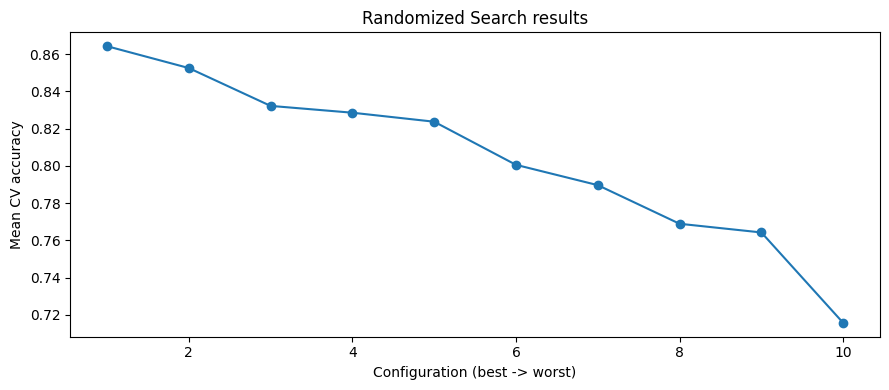

,mean_test_score,param_optimizer,param_optimizer__learning_rate,param_model__n_hidden,param_model__n_neurons,param_model__activation
2,0.864333,rmsprop,0.001,3,128,tanh
1,0.852583,adam,0.001,3,256,sigmoid
9,0.832250,rmsprop,0.010,2,256,sigmoid
3,0.828583,rmsprop,0.010,1,32,tanh
4,0.823750,rmsprop,0.010,2,64,tanh
0,0.800583,rmsprop,0.010,1,256,tanh
6,0.789667,sgd,0.010,1,32,tanh
7,0.768917,rmsprop,0.010,1,256,tanh
5,0.764250,sgd,0.010,1,64,sigmoid
8,0.715667,rmsprop,0.010,3,256,tanh


In [15]:
import pandas as pd
res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")

plt.figure(figsize=(9,4))
plt.plot(range(1, len(res)+1), res["mean_test_score"].values, marker='o')
plt.xlabel("Configuration (best -> worst)"); plt.ylabel("Mean CV accuracy")
plt.title("Randomized Search results"); plt.tight_layout(); plt.show()

res[["mean_test_score","param_optimizer","param_optimizer__learning_rate",
     "param_model__n_hidden","param_model__n_neurons","param_model__activation"]].head(10)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7915 - loss: 0.5731 - val_accuracy: 0.8490 - val_loss: 0.4212
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8408 - loss: 0.4463 - val_accuracy: 0.8467 - val_loss: 0.4479
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8542 - loss: 0.4106 - val_accuracy: 0.8593 - val_loss: 0.4000
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8608 - loss: 0.3909 - val_accuracy: 0.8548 - val_loss: 0.4007
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8646 - loss: 0.3760 - val_accuracy: 0.8632 - val_loss: 0.3823
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8693 - loss: 0.3655 - val_accuracy: 0.8712 - val_loss: 0.3545
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8719 - loss: 0.3535 - val_accuracy: 0.8778 - val_loss: 0.3509
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8758 - loss: 0.3475 -

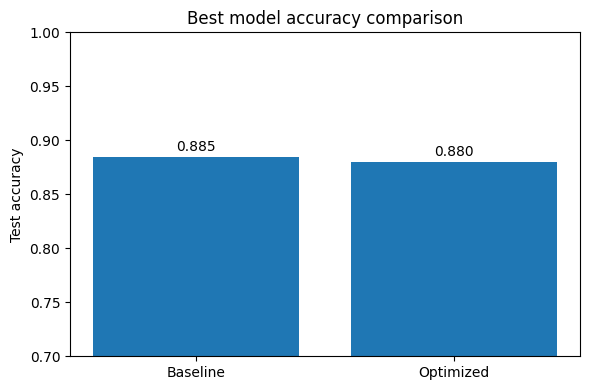

In [16]:
best = search.best_params_

opt_model = get_mlp({"n_features_in_":784, "n_classes_":10},
                    n_hidden=best["model__n_hidden"],
                    n_neurons=best["model__n_neurons"],
                    activation=best["model__activation"],
                    dropout=best["model__dropout"])

opt_map = {"sgd":keras.optimizers.SGD, "adam":keras.optimizers.Adam,
           "rmsprop":keras.optimizers.RMSprop}
optimizer = opt_map[best["optimizer"]](learning_rate=best["optimizer__learning_rate"])
opt_model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
opt_model.fit(x_train_flat, y_train, validation_split=0.1,
              epochs=best["epochs"], batch_size=best["batch_size"], verbose=1)
opt_train_time = time.time() - t0

y_pred_opt = np.argmax(opt_model.predict(x_test_flat), axis=1)
opt_acc  = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='macro')
opt_rec  = recall_score(y_test, y_pred_opt, average='macro')
opt_f1   = f1_score(y_test, y_pred_opt, average='macro')

compare = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1-score","Train time (s)"],
    "Baseline":[acc, prec, rec, f1, baseline_train_time],
    "Optimized":[opt_acc, opt_prec, opt_rec, opt_f1, opt_train_time],
})
print(compare.to_string(index=False))

plt.figure(figsize=(6,4))
plt.bar(["Baseline","Optimized"], [acc, opt_acc])
plt.ylim(0.7, 1.0); plt.ylabel("Test accuracy"); plt.title("Best model accuracy comparison")
for i,v in enumerate([acc, opt_acc]):
    plt.text(i, v+0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()